# Linear regression
Problem:  
Given dataset $(x_i, y_i)_{i=1}^{M}$  
We assume that $ (x, y) $ pairs were genearted with $ y = a * x + b + \epsilon $  
$ \epsilon $ - Gaussian noise

We want to find $a, b$ given observations $x, y$

Find approximation $ \hat{y}=a^*x+b^* $ that minimizes mean square error $L = \frac{1}{m}\sum_{i=1}^{M}(y_i-\hat{y})^2 = \frac{1}{m}\sum_{i=1}^{M}(y_i-(a^**x+b^*))^2$  
We need to find parameters $a, b$

# Generate data

In [61]:
import numpy as np
n_samples = 100
x = np.linspace(-5, 5, 100) # data
a = 0.5 #slope
b = -0.8 #bias of the line
y = a * x + b + np.random.randn(n_samples)  # target / observations #IF u remove the noise,it is a line
# Given observed pairs (x, y), we want to find a, b that minimizes mean square error
#we want to find the a and b's that fit our line the best.

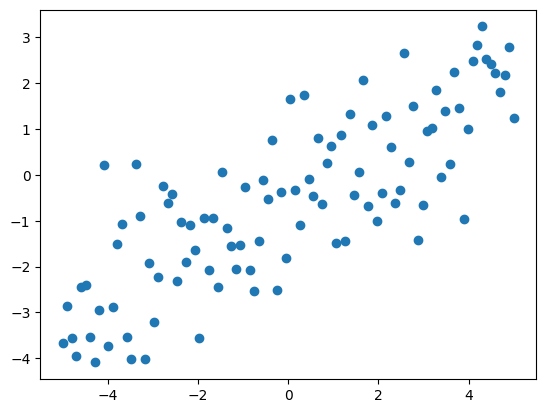

In [62]:
%matplotlib inline
import matplotlib.pyplot as plt
# TODO - Plot data 
plt.scatter(x,y) #the pb here is ur gixen an x, and u want to predict the y based on that x. All of them are a scalar.
#classic way to generate the data is to make a line and then add some noise to it. We want to predict the line that is under

In [63]:
# TODO - Plot some random models (for random a's and b's) and gt data

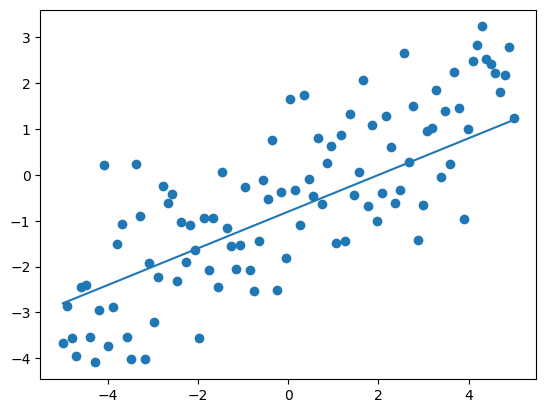

In [64]:
plt.scatter(x,y)
x_data=np.linspace(-5,5,100)
y_hat= 0.4*x-0.8
plt.plot(x_data,y_hat)

# PyTorch datasets
Some default implementations available: https://pytorch.org/docs/stable/data.html  
For images: https://pytorch.org/docs/stable/torchvision/datasets.html#imagefolder  
**Dataset** must implement __getitem__(index) (returns indexed element) and __len__() (returns number of elements)  
We could use **TensorDataset** but let's write it

In [65]:
import torch
from torch.utils.data import Dataset

class NumpyDataset(Dataset): #NumpyDataset is a subclass of Dataset, so that Dataloader can call it
    def __init__(self, data, target):
        # TODO - define class variables
        #self.data_path= ... do this so u know the path of the data but not load the whole data at once
        self.data= data
        self.target=target
        
        
    def __getitem__(self, index):
        # Anything could go here, e.g. image loading from file or a different structure
        # TODO - return data
        #get whatever data u need, not all at once. Open the path and return it into the data loader to access the item
        return torch.tensor([self.data[index]]).to(torch.float32), torch.tensor([self.target[index]]).to(torch.float32)
        #important: integers would break training, we need floats! GPUs are optimized for float32. Gradients use floats
        #alternative that should also work: torch.tensor(self.data[index], dtype=torch.float32)
    def __len__(self):
        # TODO - return the size of the dataset
        return len(self.data)

In [66]:
dataset = NumpyDataset(x, y) #x is 'data', the input, and y is target, the output
# important: torch.tensor(self.data[index]) is a scalar (0D tensor) and we need
#torch.tensor([self.data[index]]), which is a 1D tensor
#e.g.: self.data = [1, 2, 3]; self.target= [2,4,6]
#dataset is of the form: dataset[[data],[target]]
#so for e.x. dataset[4] prints (tensor([-4.5960]), tensor([-2.2690]))

In [67]:
dataset[4]
#dataset[4] = (data[4], target[4])

(tensor([-4.5960]), tensor([-2.4536]))

In [68]:
x[4], y[4]

(np.float64(-4.595959595959596), np.float64(-2.4536028175420554))

**DataLoader** objects provide a way to efficiently iterate over datasets https://pytorch.org/docs/stable/data.html

In [69]:
from torch.utils.data import DataLoader
# Create dataloader for dataset
dataloader = DataLoader(dataset, batch_size=10, shuffle=True, num_workers=0)  # num_workers = n - how many threads in background for efficient loading; when ds is very large, useful to use more than 1 worker. 
#Your training data stops between batches to load the new data, increasing this number makes that process faster 
#shuffle is if ur data is sorted, the data will get shuffled. U want each batch to contain random data, not data in order from class 1, then class2 etc how it is often organized in datasets
#if u do dont shuffle, at the 2nd step during the training, it would forget everything about what it learned in step 1

In [70]:
# We can iterate over the dataset
for xs, ys in dataloader:
    print(xs.size(), ys.size())

torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])
torch.Size([10, 1]) torch.Size([10, 1])


## PyTorch models
Pytorch models are defined as **Module** objects that need to have a **forward** method implemented that applies transformations (neural network layers) on data. https://pytorch.org/docs/stable/nn.html

In [82]:
import torch.nn as nn #linear CNN etc, known modules in DL already implemented in nn
class LinearModel(nn.Module):
    
    def __init__(self, input_dim):
        super(LinearModel, self).__init__()
        # TODO - define a linear model 
        #specify what layer u want to use: one cnn one rnn etc
        self.layer1= nn.Linear(input_dim,1) # 1 is n_classes
        #self.layer2= nn.Linear(1,1)

        #W * input+ B
     
        
    def forward(self, input):
        #TODO Apply = input * A + b. A, b are parameters of nn.Linear that we want to learn
        #specifiy how ur input goes to this layer
        x=self.layer1(input)
        #x=self.layer2(x)
        return x
        

In [83]:
# Create model
model = LinearModel(input_dim=1)  # dimensionality of x

In [84]:
model.layer1.weight, model.layer1.bias

(Parameter containing:
 tensor([[0.5499]], requires_grad=True),
 Parameter containing:
 tensor([-0.8680], requires_grad=True))

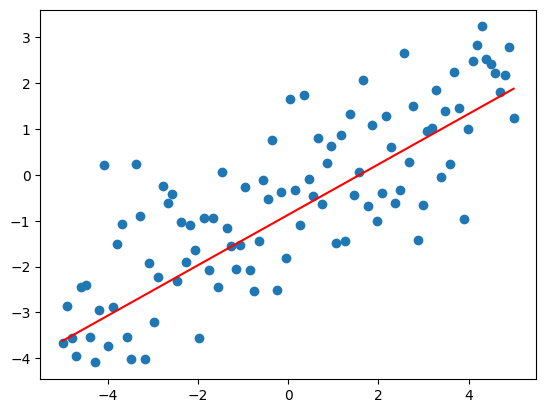

In [85]:
# TODO Plot the initial model
plt.scatter(x, y) #this suffices

#the rest is for the line and details
x_data = torch.linspace(-5, 5, 100)
y_hat = model(x_data.view(-1, 1)).flatten().detach().numpy()
plt.plot(x_data, y_hat, c="red")

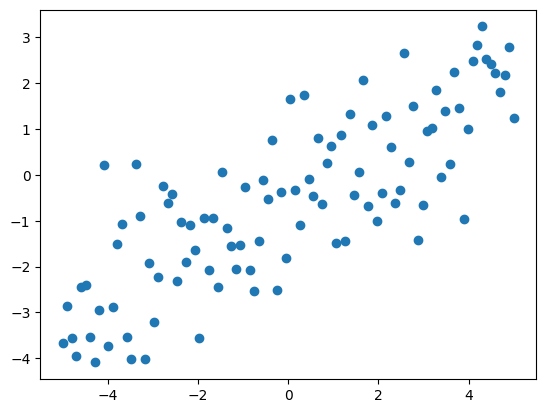

In [86]:
plt.scatter(x,y)

In [88]:
from utils import train_mse
# TODO -  train model
train_mse(dataloader, model, n_epochs=100, device=torch.device("cpu"))

  0%|          | 0/100 [00:00<?, ?it/s]

In [90]:
# TODO - Print model weights
print(model.layer1.weight), print(model.layer1.bias)

Parameter containing:
tensor([[0.5108]], requires_grad=True)
Parameter containing:
tensor([-0.5976], requires_grad=True)


(None, None)

# Use the model for prediction

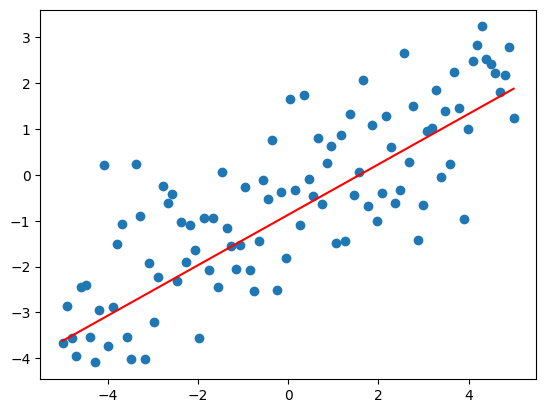

In [93]:
# TODO  - plot the final model and the GT  model
plt.scatter(x,y) #the initial data

x_data = torch.linspace(-5,5,100) #new inputs
y_hate = model(x_data.view(-1,1)).flatten().detach().numpy() #predictions; -1 in x_data.view(-1, 1) means the size is 'automatically infered'
#.detach() → remove gradient tracking
#.numpy() → convert tensor → NumPy (for plotting)
plt.plot(x_data, y_hat, c="red") #plot line